In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-sentiment-twitter-corpus' dataset.
Path to dataset files: /kaggle/input/arabic-sentiment-twitter-corpus


In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

Streaming output truncated to the last 5000 lines.
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/26001.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/1311.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/20739.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/25004.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/22666.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/13588.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/11461.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/9082.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/1045.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/5608.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/14599.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/14606.txt
/kaggle/input/arabic-sentiment-twitter-corpus/arabic_tweets/neg/2

In [4]:
train_pos_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
train_neg_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/train_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)
test_pos_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_positive_20190413.tsv', sep='\t', header=None)
test_neg_df = pd.read_csv('/kaggle/input/arabic-sentiment-twitter-corpus/test_Arabic_tweets_negative_20190413.tsv', sep='\t', header=None)

In [5]:
train_df = pd.concat([train_pos_df, train_neg_df], ignore_index=True)
test_df = pd.concat([test_pos_df, test_neg_df], ignore_index=True)

In [6]:
train_df.shape

(45275, 2)

In [7]:
for df in [train_df, test_df]:
    df.columns = ['label', 'tweet']

In [8]:
train_df.head()

,label,tweet
0,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2,pos,من الخير نفسه 💛
3,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...


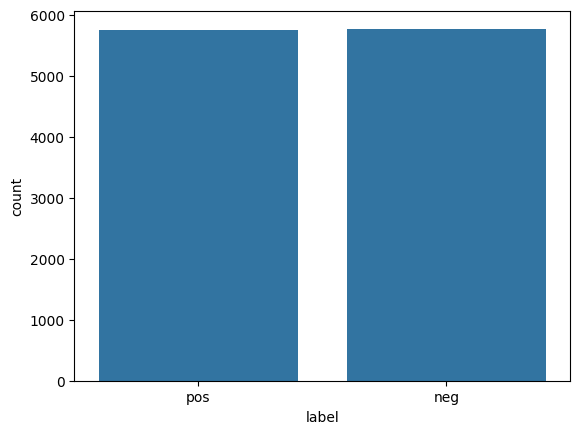

In [9]:
sns.countplot(data=df,x ='label')
plt.show()

# Pre Processing

## Remove Punctuation

In [10]:
import string

In [11]:
punct=string.punctuation

In [12]:
punct

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [13]:
def remove_punct(text):
    text_nonpunct=''.join([char for char in text if char not in punct])
    return text_nonpunct

In [14]:
df['tweet']=df['tweet'].apply(lambda x:remove_punct(x.lower()))
df['tweet']

,tweet
0,الهلالالاهلي فوز هلالي مهم الحمد لله 💙 زوران ك...
1,صباحك خيرات ومسرات 🌸
2,تأمل قال الله ﷻ ​﴿بواد غير ذي زرع ﴾ 💫💫 ✍ ومع...
3,😂😂 يا جدعان الرجاله اللي فوق ال دول خطر ع تويت...
4,رساله صباحيه 💛 اللهم اسألك التوفيق في جميع ام...
...,...
11515,النوم وانت مكسور ده احساس غبي اللي هو مش قادر ...
11516,استشهادالامامكاظمالغيظ السلام على المعذب في قع...
11517,انا كنت اكل الصحن بكبره 😐
11518,قولوا لي ايش تشوفوا مع ملاحظة التلطف لأنه الم...


## Removing Digits

In [15]:
import re
def remove_digits(text):
    return re.sub(r'\d+', '', text)  # \d matches digits

df['tweet'] = df['tweet'].apply(remove_digits)

In [16]:
pip install emoji

In [17]:
import emoji

df['tweet'] = df['tweet'].apply(emoji.demojize)
df['tweet']

,tweet
0,الهلالالاهلي فوز هلالي مهم الحمد لله :blue_hea...
1,صباحك خيرات ومسرات :cherry_blossom:
2,تأمل قال الله ﷻ ​﴿بواد غير ذي زرع ﴾ :dizzy::d...
3,:face_with_tears_of_joy::face_with_tears_of_jo...
4,رساله صباحيه :yellow_heart: اللهم اسألك التوف...
...,...
11515,النوم وانت مكسور ده احساس غبي اللي هو مش قادر ...
11516,استشهادالامامكاظمالغيظ السلام على المعذب في قع...
11517,انا كنت اكل الصحن بكبره :neutral_face:
11518,قولوا لي ايش تشوفوا مع ملاحظة التلطف لأنه الم...


## Remove Stopwords

In [18]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
StopWords=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
StopWords[:5]

['a', 'about', 'above', 'after', 'again']

In [20]:
def remove_stopwords(text):
    filtered_text = ' '.join(word for word in text.split() if word.lower() not in StopWords)
    return filtered_text

df['tweet']=df['tweet'].apply(lambda x : remove_stopwords(x))

## Tokenization

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [22]:
tokenizer = Tokenizer(
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(df['tweet'])

In [23]:
df['tweet'] = tokenizer.texts_to_sequences(df['tweet'])

In [24]:
for word, index in tokenizer.word_index.items():
    print(word, index)
    if index == 10:
        break

<OOV> 1
face 2
heart 3
من 4
with 5
في 6
الله 7
broken 8
على 9
و 10


In [25]:
vocab_size = len(tokenizer.word_index)

In [26]:
df.head()

,label,tweet
0,pos,"[210, 90, 778, 1131, 96, 66, 14, 3, 664, 63, 8..."
1,pos,"[285, 8178, 13279, 52, 45]"
2,pos,"[1063, 124, 7, 952, 1202, 129, 564, 1064, 398,..."
3,pos,"[2, 5, 12, 11, 13, 2, 5, 12, 11, 13, 21, 2443,..."
4,pos,"[2180, 4556, 44, 3, 23, 1804, 1805, 6, 1065, 4..."


In [27]:
from collections import Counter

# Compute sequence lengths
sequence_lengths = [len(seq) for seq in df['tweet']]

# Count frequencies of each length
length_counts = Counter(sequence_lengths)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [28]:
length_counts.most_common(5)

[(20, 692), (8, 660), (7, 654), (19, 566), (5, 556)]

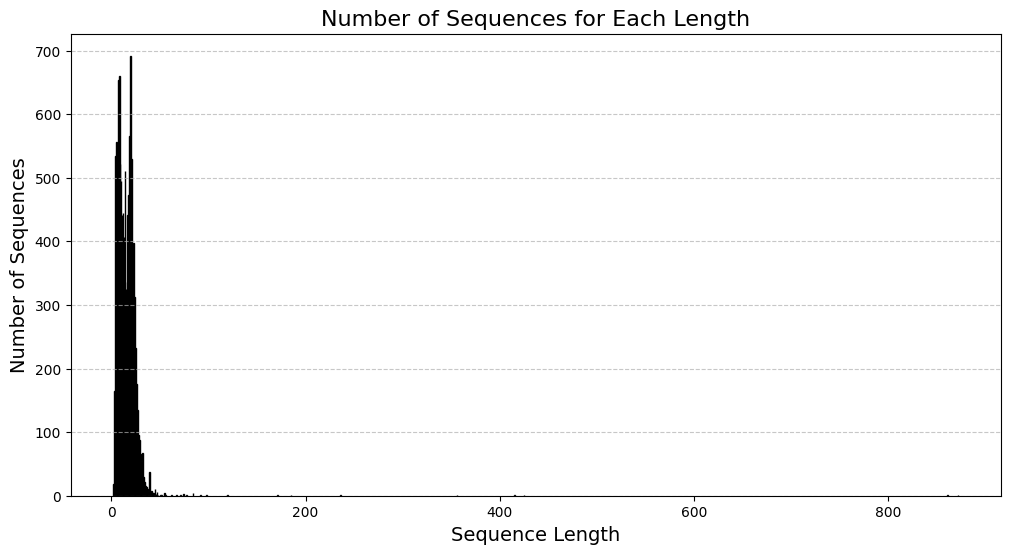

In [29]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')
plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [30]:
input_shape = 70

## Padding

In [31]:
# Sequence Padding
from tensorflow import  keras
from keras.preprocessing.sequence import pad_sequences
X=pad_sequences(df['tweet'],
    maxlen=input_shape,
    padding='post',
    truncating='post',
)

## Labeling Target

In [32]:
y=df['label']

In [33]:
from sklearn.preprocessing import LabelEncoder
LB=LabelEncoder()
y=LB.fit_transform(y)

## Splitting

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=100) # encoded_matrix
print("X_train : \n",X_train)
print("X_test  : \n",X_test)


X_train : 
 [[  714    64   422 ...     0     0     0]
 [   21   684    10 ...     0     0     0]
 [    6 20508 20509 ...     0     0     0]
 ...
 [    7  3730   249 ...     0     0     0]
 [  236   290  3424 ...     0     0     0]
 [   23    15  1941 ...     0     0     0]]
X_test  : 
 [[  169   818    67 ...     0     0     0]
 [ 1108   581   981 ...     0     0     0]
 [   35   581   576 ...     0     0     0]
 ...
 [  694 11812  1977 ...     0     0     0]
 [   96    66    14 ...     0     0     0]
 [ 1591  6504   299 ...     0     0     0]]


In [35]:
print("X_train shape : ",X_train.shape)
print("X_test  shape : ",X_test.shape)

X_train shape :  (9216, 70)
X_test  shape :  (2304, 70)


# RNN Model

In [36]:

# Define the model
model = tf.keras.models.Sequential([
    # Embedding layer
    tf.keras.layers.Embedding(vocab_size+1, 32, input_shape=[input_shape]),  # Embedding layer

    # RNN layer
    tf.keras.layers.SimpleRNN(32, return_sequences=True),  # RNN layer

    # Batch Normalization after RNN
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # RNN layer
    tf.keras.layers.SimpleRNN(32, return_sequences=False),  # RNN layer

    # Batch Normalization after RNN
    tf.keras.layers.BatchNormalization(),  # Batch Normalization

    # Dropout layer for regularization
    tf.keras.layers.Dropout(0.25),  # Dropout layer

    # Dense output layer with softmax activation for multi-class classification
    tf.keras.layers.Dense(4, activation="sigmoid")  # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 70, 32)         │     1,080,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 70, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 70, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085,412 (4.14 MB)

 Trainable params: 1,085,284 (4.14 MB)

 Non-trainable params: 128 (512.00 B)

None


In [42]:
# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer="adam", metrics=["accuracy"])

# Training and evaluating the model
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.6727 - loss: 0.6609 - val_accuracy: 0.5027 - val_loss: 2.5265
Epoch 2/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8894 - loss: 0.2949 - val_accuracy: 0.6979 - val_loss: 0.5681
Epoch 3/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9601 - loss: 0.1284 - val_accuracy: 0.7218 - val_loss: 1.1457
Epoch 4/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9825 - loss: 0.0625 - val_accuracy: 0.7131 - val_loss: 2.0327
Epoch 5/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9824 - loss: 0.0579 - val_accuracy: 0.5049 - val_loss: 3.0076
Epoch 6/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9853 - loss: 0.0491 - val_accuracy: 0.7354 - val_loss: 0.7639
Epoch 7/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9893 - loss: 0.0406 - val_accuracy: 0.7283 - val_loss: 1.5343
Epoch 8/25
231/231 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9924 - loss: 0.0329 - val_

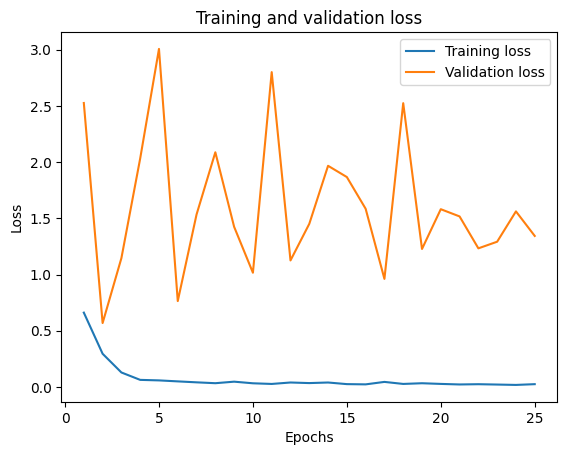

In [43]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

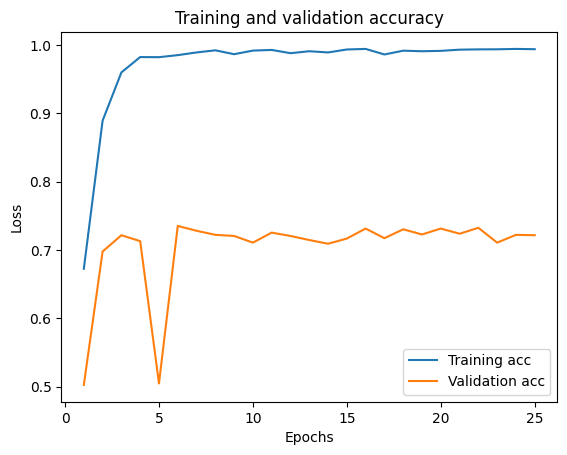

In [44]:

plt.clf()   # clear figure
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [45]:
# Confusion Matrix
y_pred = (model.predict(X_test).argmax(axis=-1)).tolist()

class_names = LB.classes_

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification report : 
               precision    recall  f1-score   support

         neg       0.76      0.75      0.75      1180
         pos       0.74      0.75      0.74      1124

    accuracy                           0.75      2304
   macro avg       0.75      0.75      0.75      2304
weighted avg       0.75      0.75      0.75      2304



Confusion matrix : 



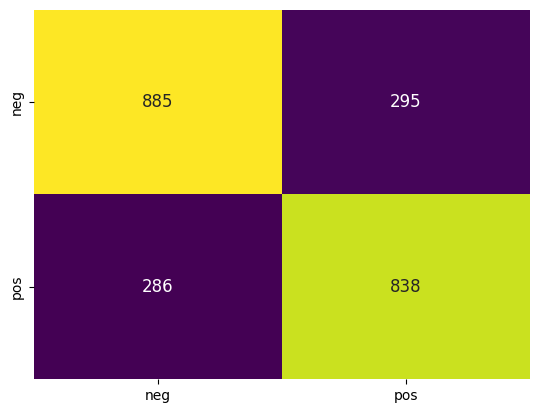

Normalized confusion matrix : 



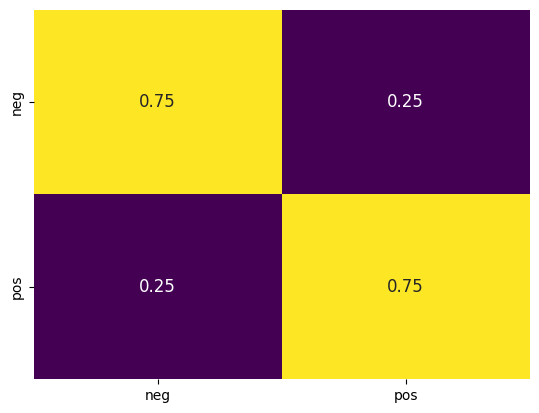

In [46]:
# Function to draw confusion matrix
def draw_confusion_matrix(true, preds, normalize=None):
  # Compute confusion matrix
  conf_matx = confusion_matrix(true, preds, normalize = normalize)
  conf_matx = np.round(conf_matx, 2)
  # print(conf_matx)

  # plt.subplots(figsize=(14,8))
  sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis",xticklabels=class_names,yticklabels=class_names)
  plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred,"true")